Simulate and fit a AutoRegressive AR(1) Vasicek Model
<center> $X_t = \alpha X_{t-1} + \epsilon_t$ </center>
<center> $\epsilon_t \sim N(0, 1 - \alpha^2)$ </center>
<center> $h(X_t) \equiv \Phi[\frac{\Phi^{-1}(PD) - \sqrt{\rho} \cdot X_t}{\sqrt{1-\rho}}]$</center>

In [1]:
# Import libraries
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.stats import norm
from jax.random import PRNGKey, split
import matplotlib.pyplot as plt
from  matplotlib.ticker import PercentFormatter
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.contrib.control_flow import scan
import arviz as az
import preliz as pz

In [2]:
print(numpyro.__version__)
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)

0.18.0


In [3]:
# Random seed and plotting style
seed = sum(map(ord, "Numpyro Vasicek Autoregressive"))
key = PRNGKey(seed)

az.style.use("arviz-doc")

Simulate a AR(1) process 
<center> $X_t = \alpha \cdot X_{t-1} + \epsilon_t$ <center>

In [4]:
α_sim = -0.25
x_sim_init = 1
ρ_sim = 0.25
PD_sim = 0.15
time_steps = 300
N_obligors = 100_000_000 # Number of obligors

def ar_1_scan(carry, t):
    '''
    Autoregressive AR(1) 
    '''
    xprev = carry

    # Autoregressive AR(1) process
    xnew = α_sim * xprev + numpyro.sample("x", dist.Normal(0, jnp.sqrt(1 - α_sim**2)))
    
    # Simulate the default Rate
    h_t = norm.cdf((norm.ppf(PD_sim, loc=0, scale=1) - jnp.sqrt(ρ_sim) * xnew)/jnp.sqrt(1 - ρ_sim), loc=0, scale=1)
    # Given default Rate Simulate number of defaults
    num_defaults = numpyro.sample("num_defaults", dist.Binomial(total_count = N_obligors, probs = h_t))
    
    return xnew, (xnew, num_defaults)

key, subkey = split(key)
ts = jnp.arange(time_steps)

# Calculate h_0
h_0 = norm.cdf((norm.ppf(PD_sim, loc=0, scale=1) - jnp.sqrt(ρ_sim) * x_sim_init)/jnp.sqrt(1 - ρ_sim), loc=0, scale=1)
n0 = jax.random.binomial(subkey, n=N_obligors, p=h_0)

with numpyro.handlers.seed(rng_seed=subkey):

    _ , (x_sim, defaults) =  scan(ar_1_scan, x_sim_init, ts[:-1])

x_sim =  jnp.concatenate([jnp.array(x_sim_init)[None], x_sim], axis=0)
dr = jnp.concatenate([n0[None], defaults], axis=0)/N_obligors
    

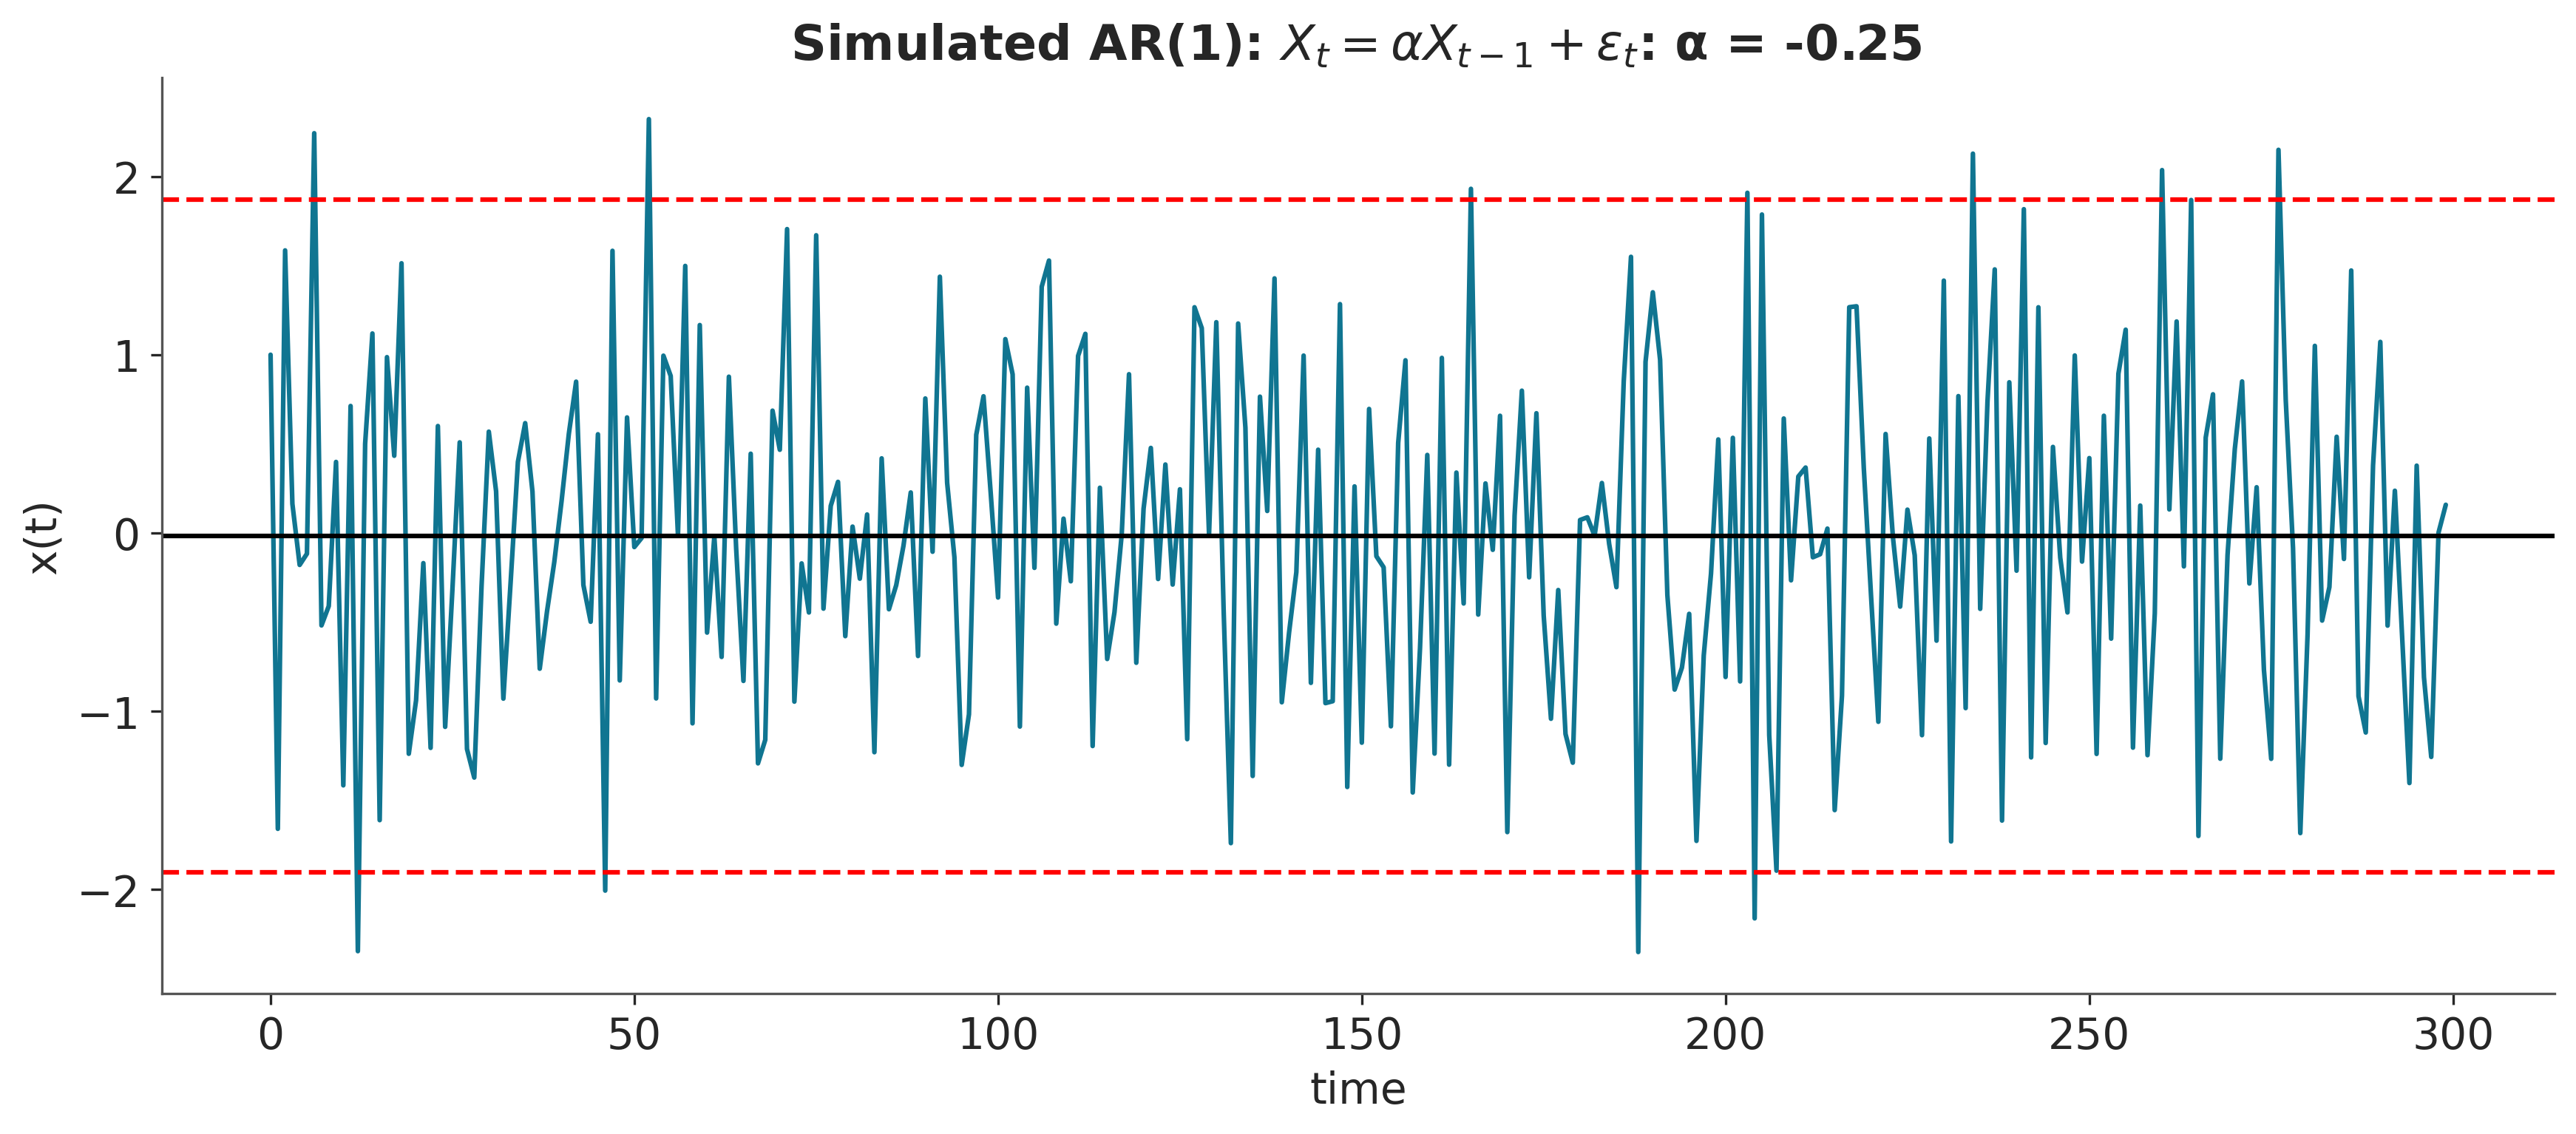

In [5]:
fig, ax = plt.subplots()
ax.plot(ts, x_sim)
ax.axhline(x_sim.mean(), color='k')
ax.axhline(x_sim.mean() + 2 * x_sim.std(), color='r', ls='--')
ax.axhline(x_sim.mean() - 2 * x_sim.std(), color='r', ls='--')
ax.set_xlabel("time")
ax.set_ylabel("x(t)")
ax.set_title(r"Simulated AR(1): $X_t = \alpha X_{t-1} + \epsilon_t$: " + f"α = {α_sim} ")
plt.show()

In [6]:
print(f"Mean of simulated AR(1) latent process is {round(x_sim.mean(), 3)}")
print(f"Standard Deviation of AR(1) latent process is {round(x_sim.std(), 3)}")

Mean of simulated AR(1) latent process is -0.015000000596046448
Standard Deviation of AR(1) latent process is 0.9440000653266907


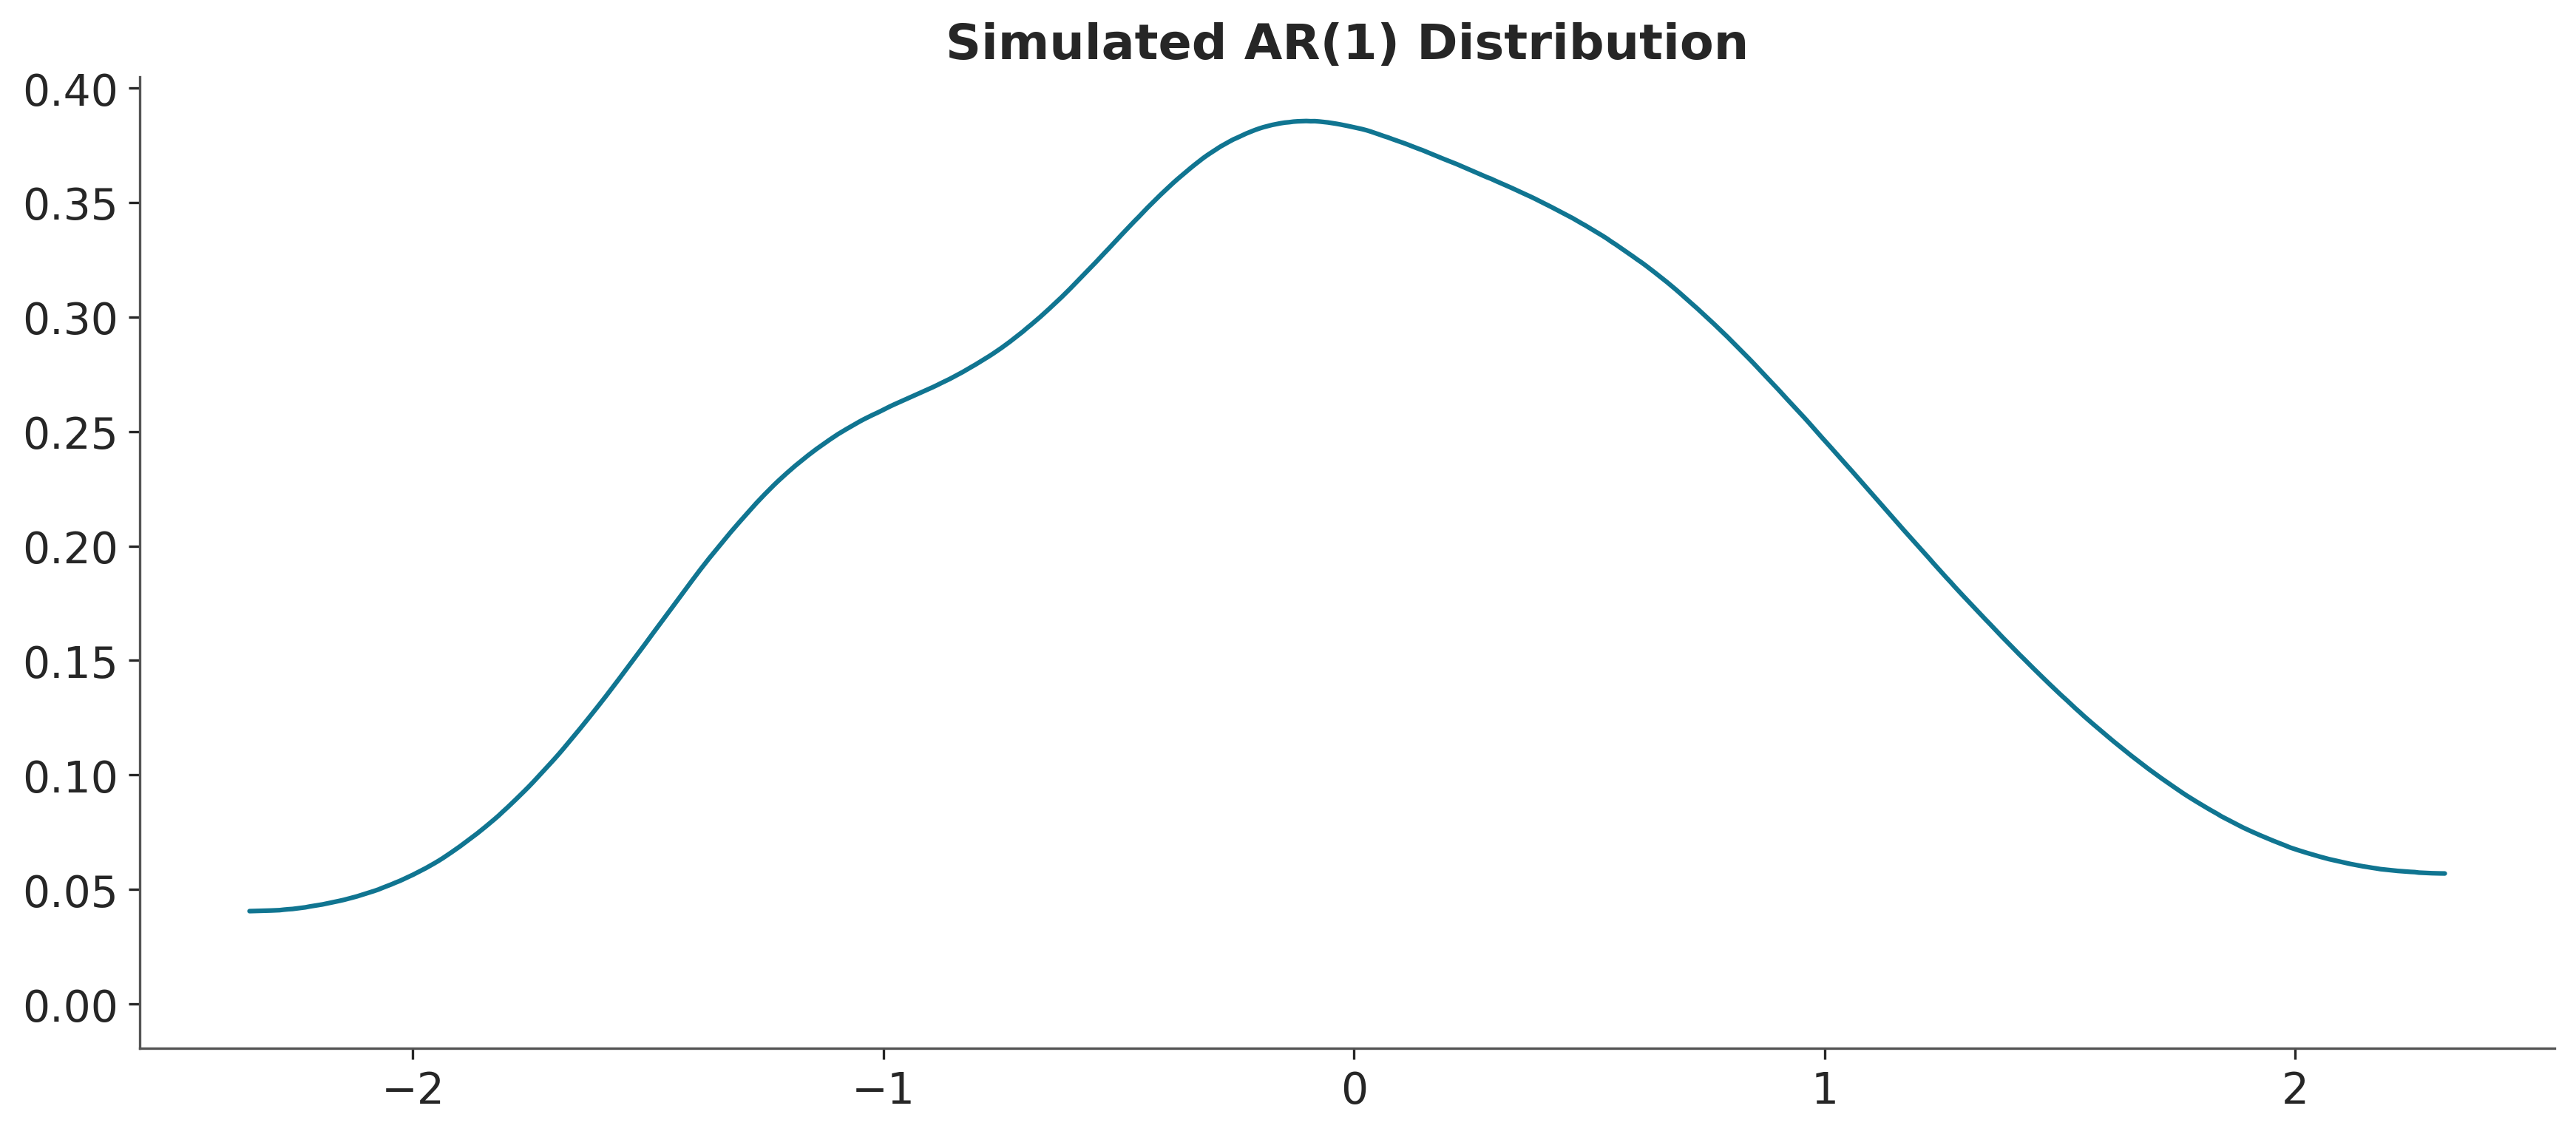

In [7]:
az.plot_dist(x_sim)
plt.title("Simulated AR(1) Distribution")
plt.show()

Split in Testing and Training Sets

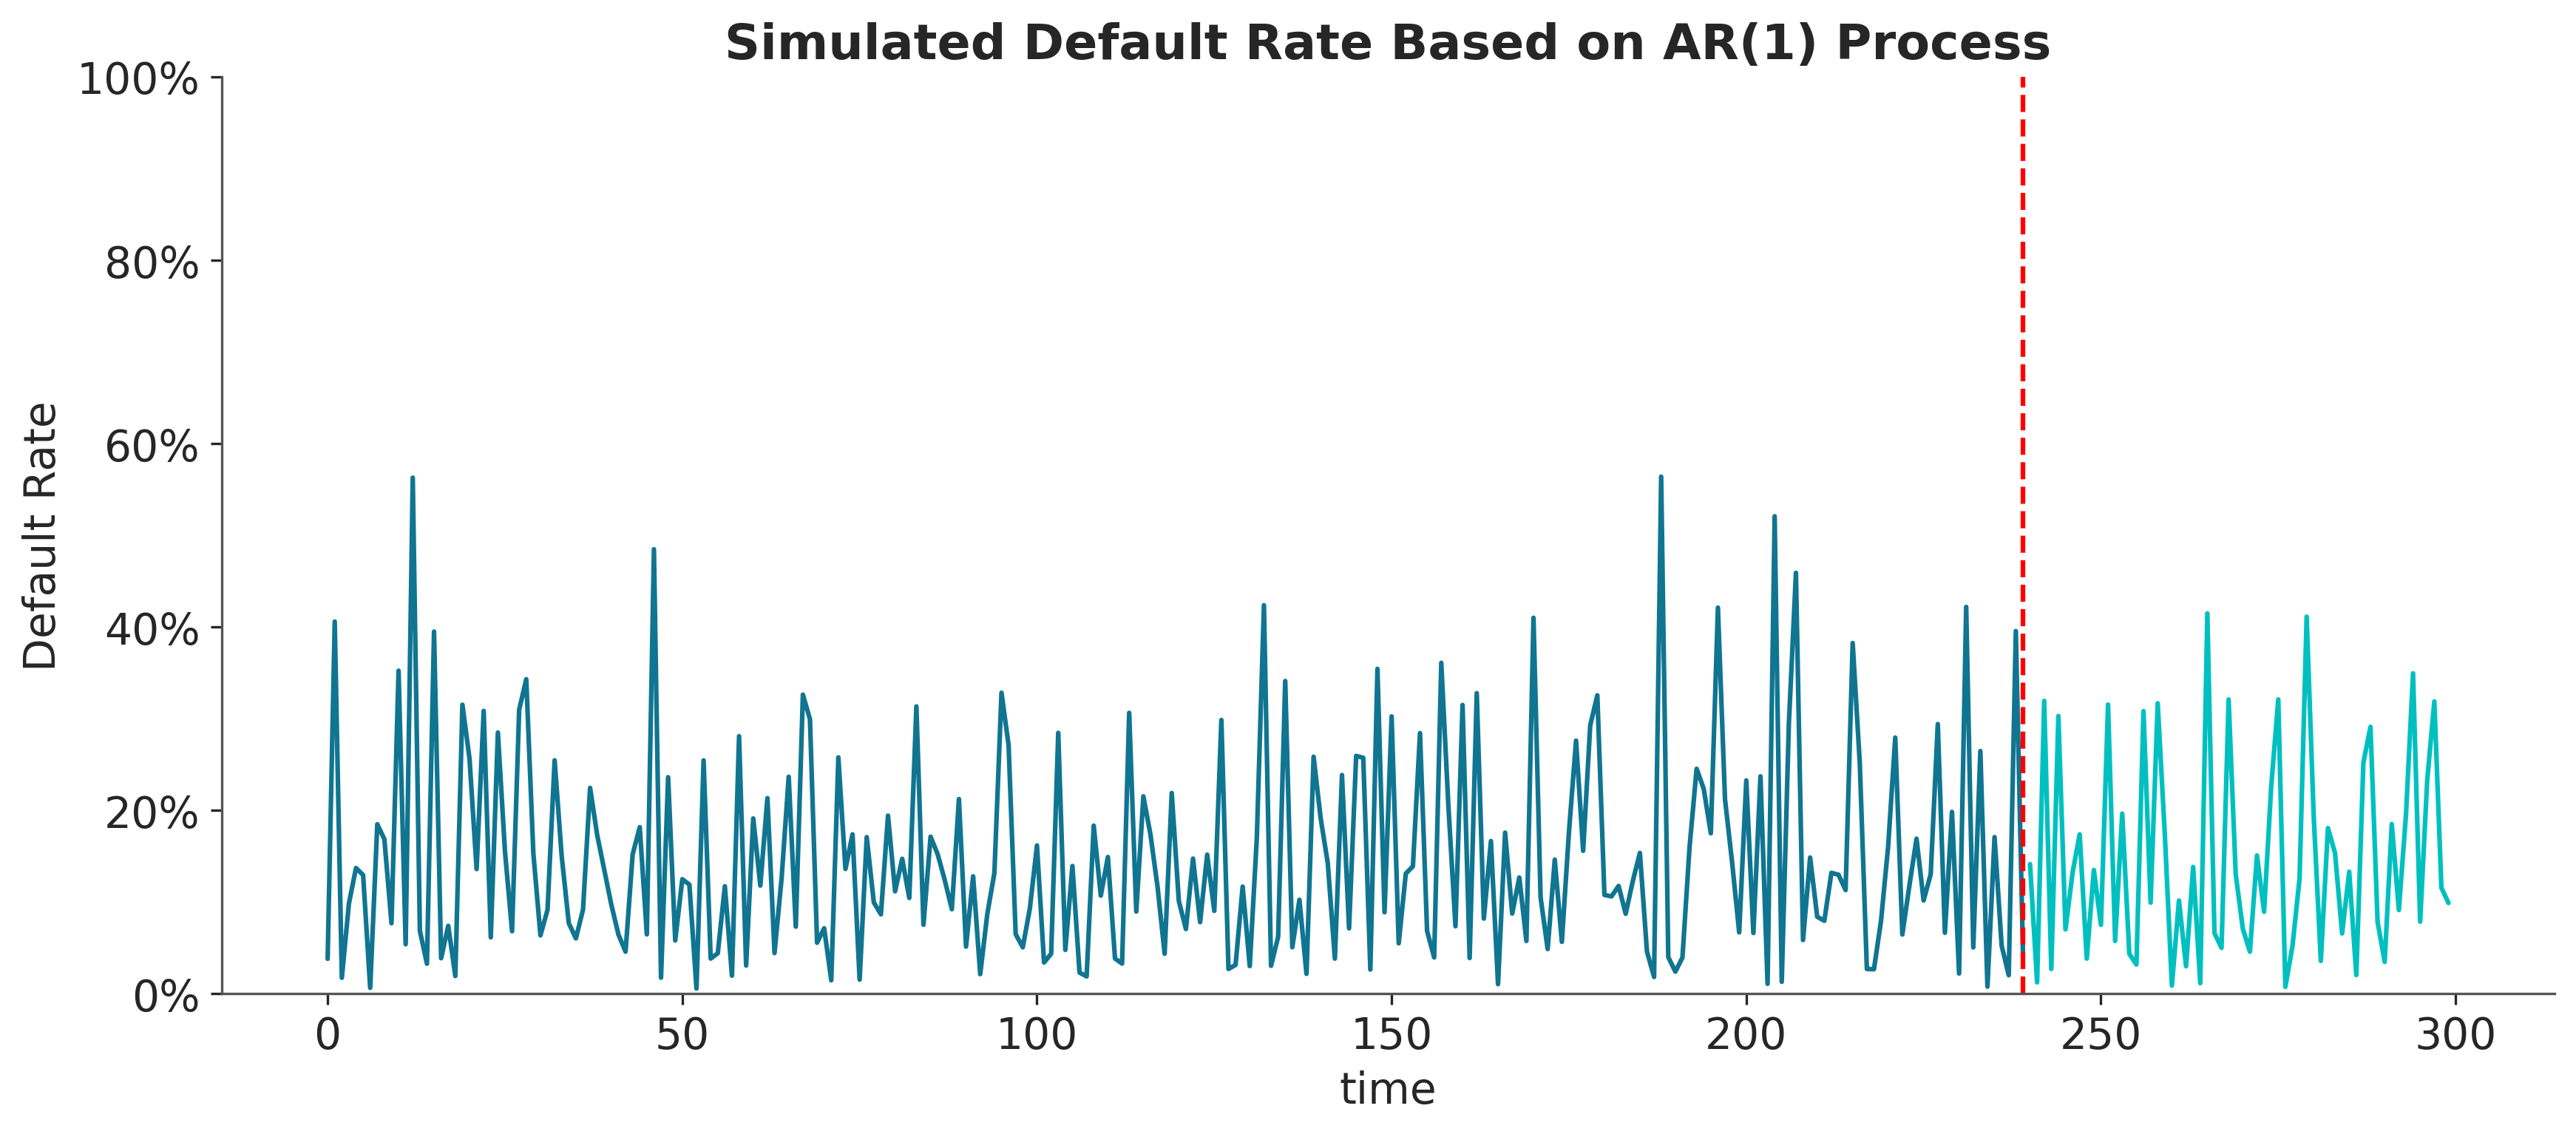

In [8]:
prop = 0.8
n_train = int(prop * len(dr))

t_train = ts[:n_train]
t_test = ts[n_train:]

dr_train = dr[:n_train]
dr_test = dr[n_train:]

fig, ax = plt.subplots()
ax.plot(t_train, dr_train)
ax.plot(t_test, dr_test, color='C1')
ax.axvline(t_train[-1], color='r', ls='--')
ax.set_ylim([0, 1])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("time")
ax.set_ylabel("Default Rate")
ax.set_title("Simulated Default Rate Based on AR(1) Process")
plt.show()

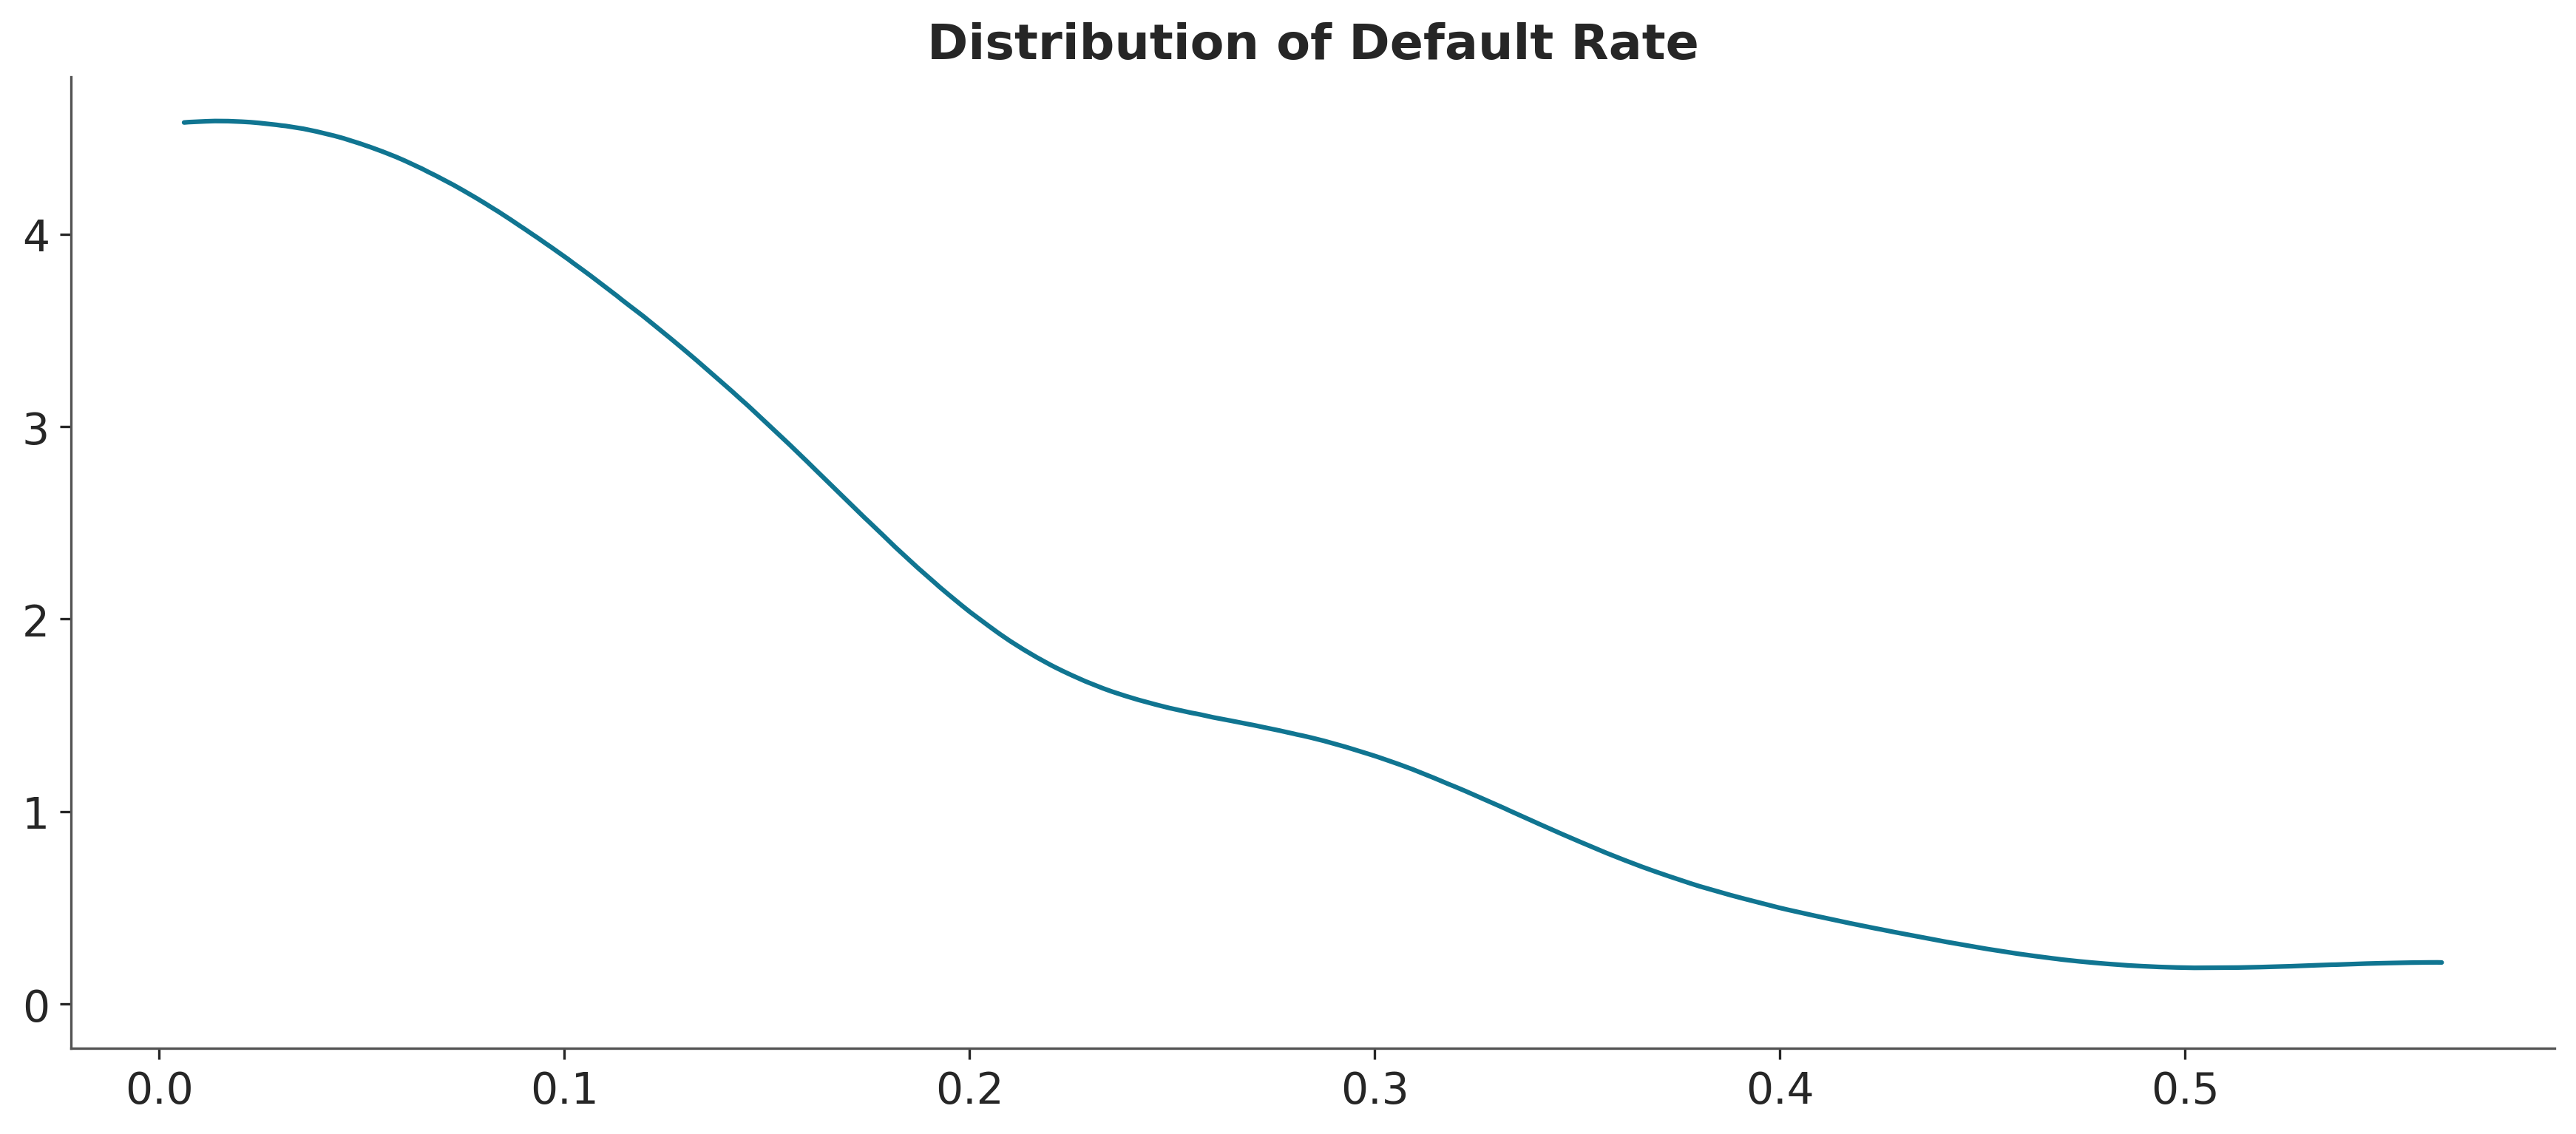

In [9]:
az.plot_dist(dr_train)
plt.title("Distribution of Default Rate")
plt.show()

Numpyro Model

(<Axes: >,
  message: Optimization terminated successfully
  success: True
   status: 0
      fun: 0.4655326901029895
        x: [ 2.086e+00  4.920e+00]
      nit: 10
      jac: [-1.034e-01  1.152e-01]
     nfev: 31
     njev: 10)

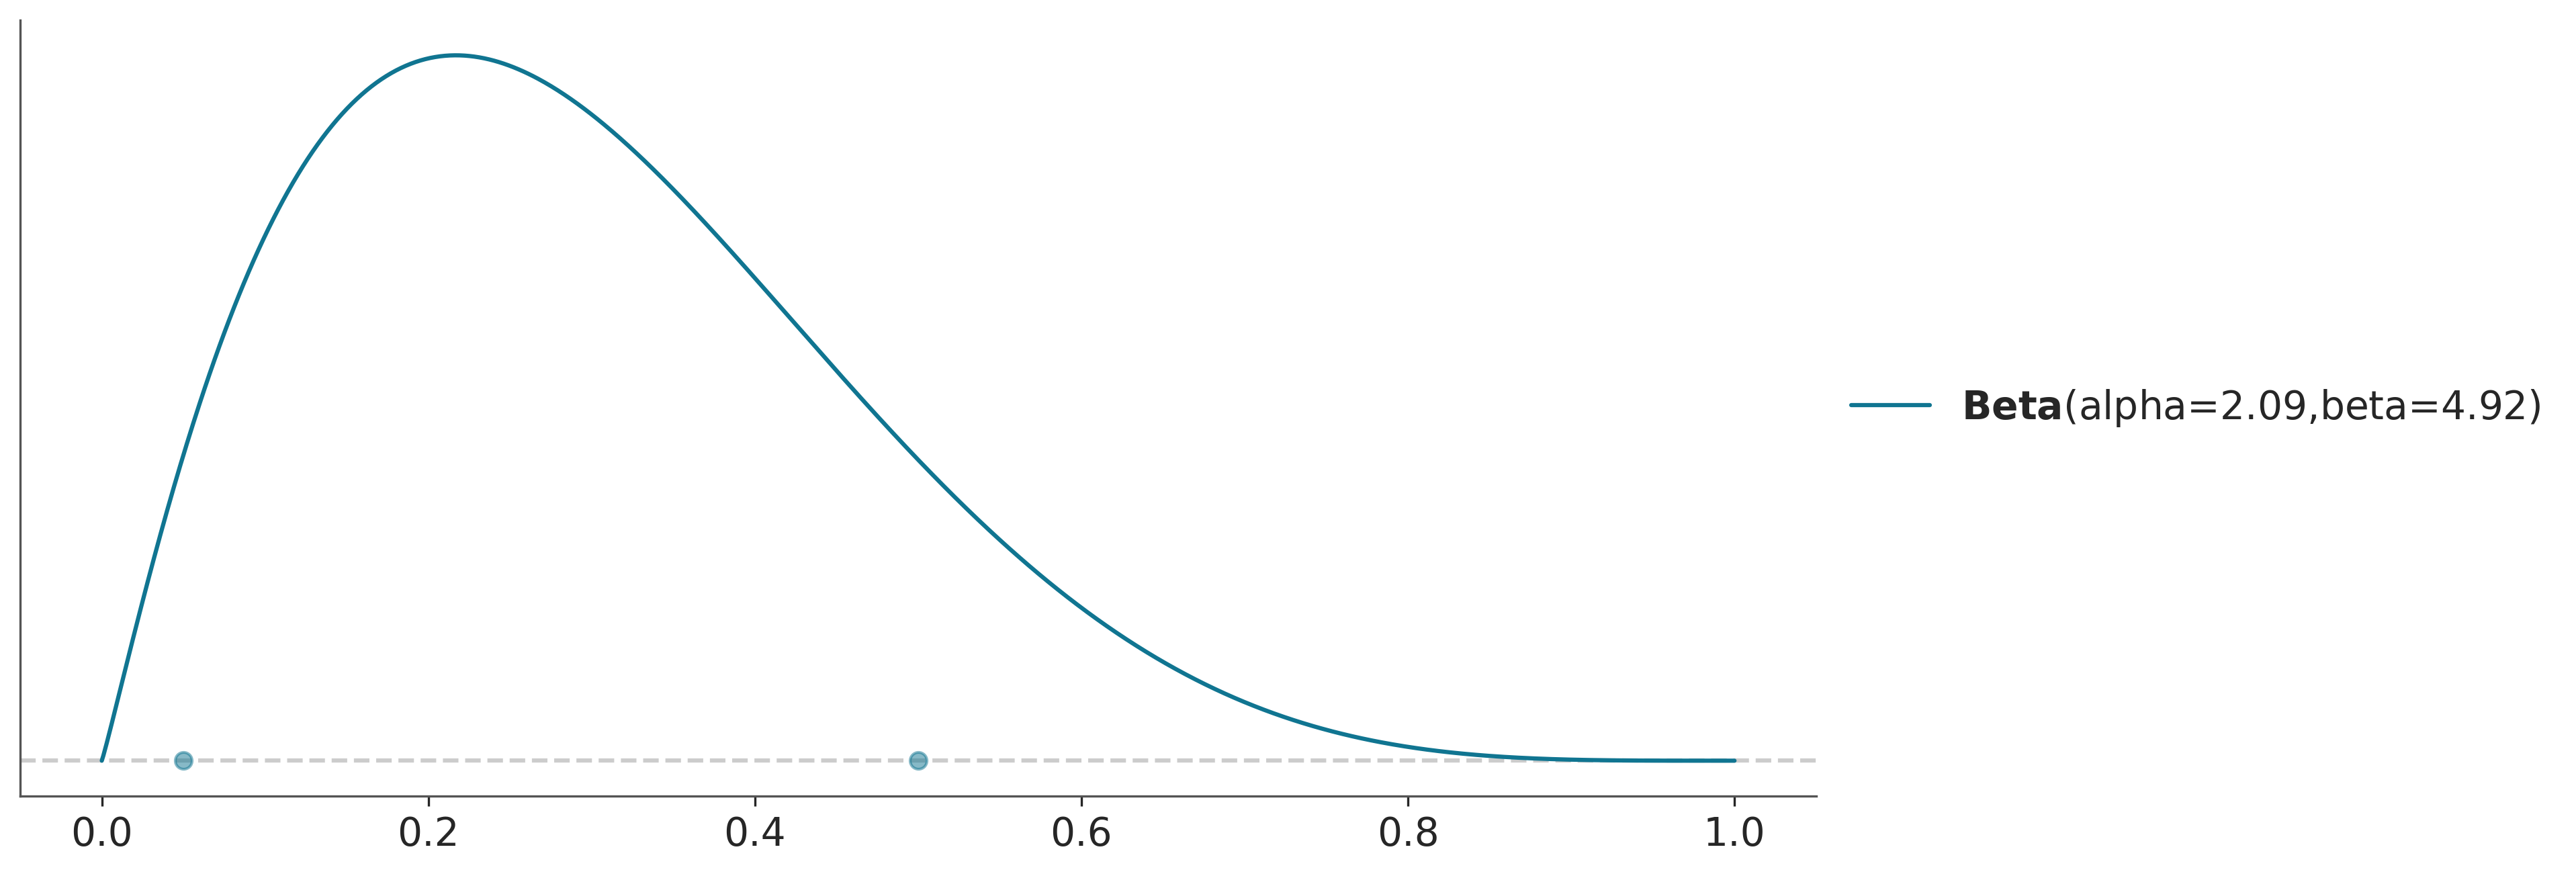

In [10]:
pz.maxent(pz.Beta(), lower=0.05, upper=0.5, mass=0.85)

In [25]:
def vasicek_ar_1(dr_obs:jnp.array, forecast:int=0, N_obligors:int=N_obligors) -> None:

    tmax = len(dr_obs) # Lenght of time series (will be used later when forecasting future)
    
    # Define priors
    α = numpyro.sample("α", dist.Uniform(low=-1., high=1.))
    ρ = numpyro.sample("ρ", dist.Uniform(low=-1., high=1.))
    PD = numpyro.sample("PD", dist.Beta(concentration0=2., concentration1=5.))

    # Initial State of default rate
    π_init = numpyro.sample("π_init", dist.Beta(concentration0=2., concentration1=5.))
    
    def logpdf_scan(carry, pi_s):
        '''
        The logpdf for the vasicek autoregressive process

        The logpdf for AR(1) process is conditional on prior default rate
        '''
        π_prev = carry
        # Mean of autoregressive process
        μ_p = α * (jnp.sqrt( 1 - ρ) * norm.ppf(π_prev, loc=0., scale=1.) - norm.ppf(PD, loc=0., scale=1.) ) / jnp.sqrt(ρ)
        # Standard Deviation
        σ_p = jnp.sqrt(1 - α**2) # Careful to take sqrt of 1 - α**2

        num_ = norm.logpdf( (jnp.sqrt(1 - ρ)*norm.ppf(pi_s, loc=0., scale=1.)
                             -
                             norm.ppf(PD, loc=0., scale=1.)
                            )/jnp.sqrt(ρ),
                            loc=μ_p,
                            scale=σ_p
                          )
        den_ = norm.logpdf(norm.ppf(pi_s, loc=0., scale=1.), loc=0., scale=1.)

        new_logpdf = jnp.log(jnp.sqrt(1 - ρ)) - jnp.log(jnp.sqrt(ρ)) + num_ - den_

        return pi_s, new_logpdf

    # Running the scan function
    _, vasicek_pdf = scan(
        logpdf_scan,
        π_init,
        dr_obs
    )

    # Loglikelihood
    log_likelihood = numpyro.factor("log_likelihood", vasicek_pdf)

    # Forecasting
    if forecast > 0:

        # Initial latent autoregressiv process
        x_forecast_init = (
            jnp.sqrt(1 - ρ)*norm.ppf(dr_obs[-1], loc=0., scale=1.) 
            - 
            norm.ppf(PD, loc=0., scale=1.)
        )/jnp.sqrt(ρ)
        
        # Create new scan function
        def forecast_scan(carry, ts):
            '''
            Scan for forecast function
            Simulate the latent AR(1) process as X_t = alpha * X_{t-1} + noise
            Noise is Normal(0, 1 - alpha**2)
            Calculate the default rate: h and use h to sample # of defaults using binomial distribution
            '''

            x_prev = carry

            x_new = α * x_prev + numpyro.sample("x", dist.Normal(loc=0., scale=jnp.sqrt(1 - α**2)))

            h = norm.cdf( 
                    (norm.ppf(PD, loc=0., scale=1.) - jnp.sqrt(ρ) * x_new)
                                /
                    jnp.sqrt(1 - ρ), 
                loc=0., scale=1.)

            num_defaults = numpyro.sample("num_defaults", dist.Binomial(total_count=N_obligors, probs=h))

            return x_new, num_defaults

        # Run the forecast using scan
        _, forecast_ = scan(forecast_scan,
                            x_forecast_init,
                            jnp.arange(tmax, tmax + forecast)
                           )
        
        # Forecast of default rate is forecast/N_obligors
        forecast = numpyro.deterministic("forecast", forecast_/N_obligors)

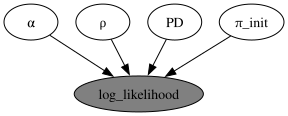

In [26]:
numpyro.render_model(vasicek_ar_1, model_kwargs={"dr_obs": dr_train})

In [27]:
type(dr_train)

jaxlib.xla_extension.ArrayImpl

In [28]:
# Run inference
rng_key, rng_subkey = split(key)
vasicek_mcmc = MCMC(NUTS(vasicek_ar_1), num_warmup = 1_000, num_samples = 2_000, num_chains=4)
vasicek_mcmc.run(rng_subkey, 
                 **{"dr_obs": dr_train})

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [29]:
# Create an arviz object and check the divergences
idata_vasicek = az.from_numpyro(vasicek_mcmc)

In [30]:
print(f"The number of divergeneces is {idata_vasicek['sample_stats']['diverging'].sum().item()}")

The number of divergeneces is 0


In [31]:
az.summary(idata_vasicek, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
PD,0.15,0.01,0.14,0.16,0.0,0.0,6036.39,5524.49,1.0
α,-0.30,0.06,-0.42,-0.19,0.0,0.0,6433.28,5465.16,1.0
π_init,0.72,0.15,0.44,0.97,0.0,0.0,7525.65,4818.05,1.0
ρ,0.23,0.02,0.20,0.27,0.0,0.0,6158.73,5847.01,1.0


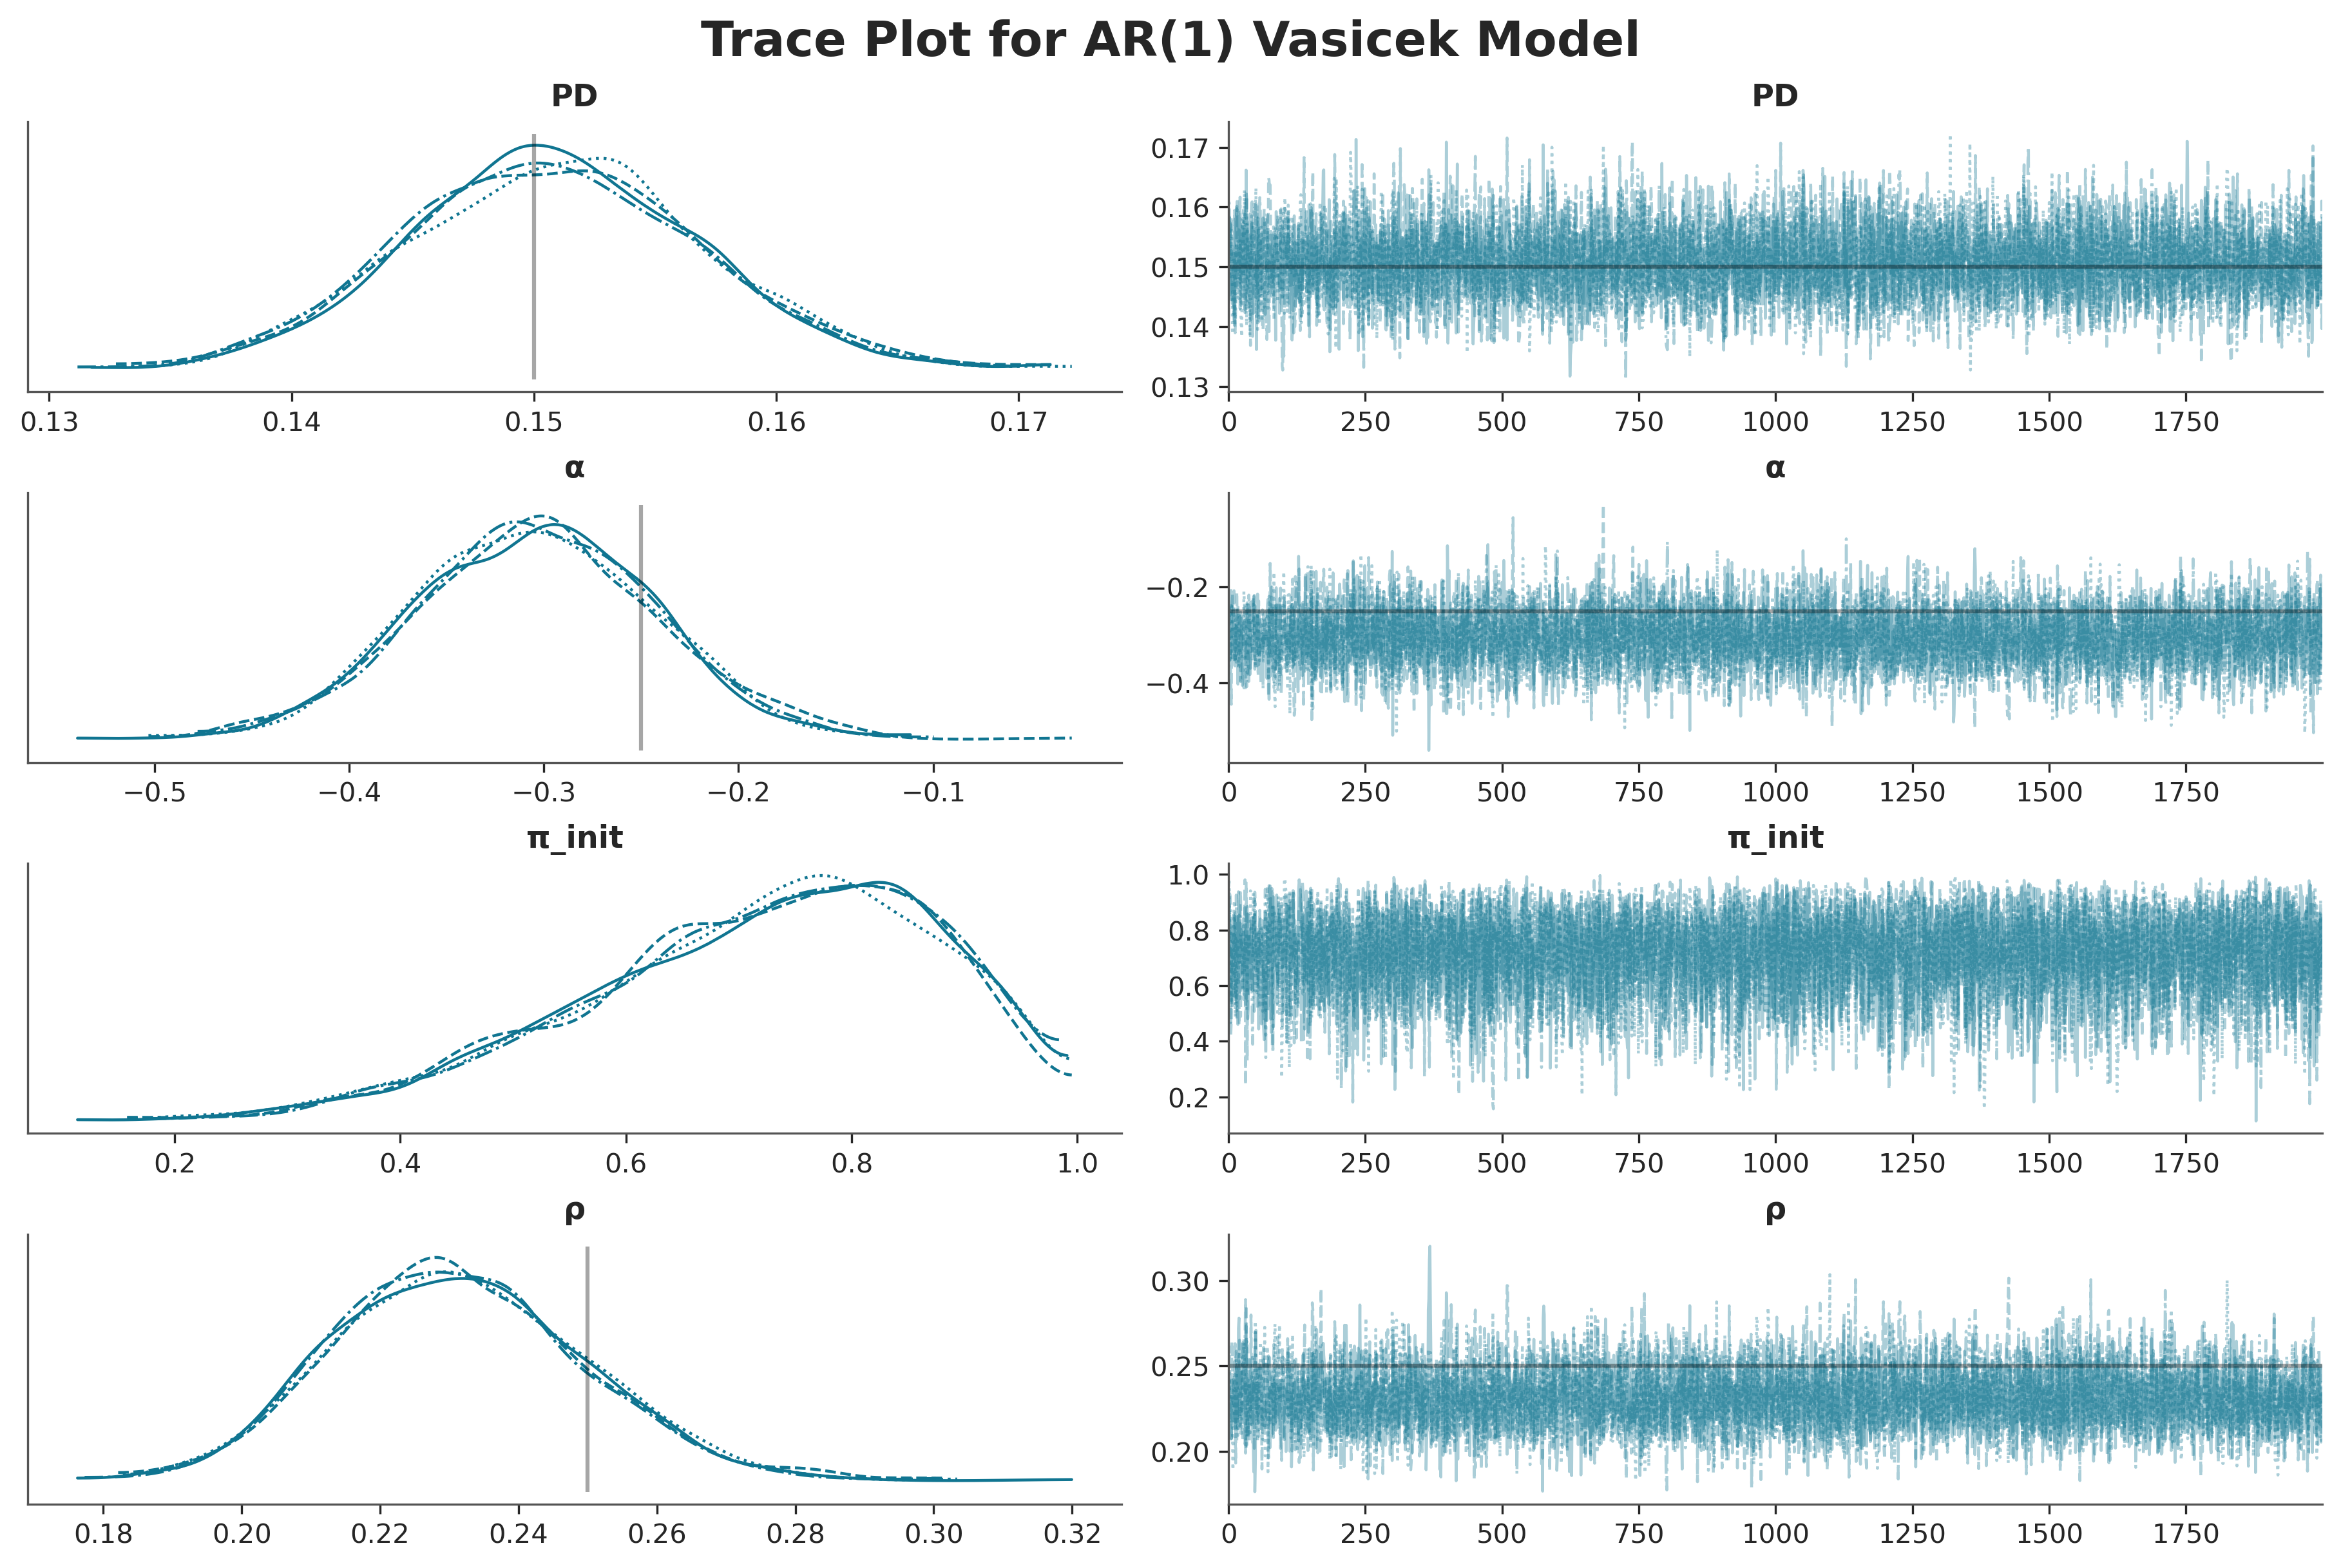

In [32]:
az.plot_trace(idata_vasicek, 
             lines = [
                 ("α", {}, α_sim),
                 ("ρ", {}, ρ_sim),
                 ("PD", {}, PD_sim)
                 ]
             )
plt.suptitle("Trace Plot for AR(1) Vasicek Model")
plt.show()

Do some forecasting

In [43]:
rng_key, rng_subkey = split(rng_key)
forecast_vasicek = Predictive(vasicek_ar_1, vasicek_mcmc.get_samples(), return_sites=["forecast"])(
    rng_subkey,
    **{"dr_obs": dr_train,
      "forecast": len(dr_test)
      }
)

Plot the forecasts

In [44]:
# Convert from numpyro to arviz object
idata_vasicek_forecast = az.from_numpyro(
    posterior_predictive = forecast_vasicek,
    coords = {"time_forecast": t_test},
    dims = {"forecast": ["time_forecast"]}
)

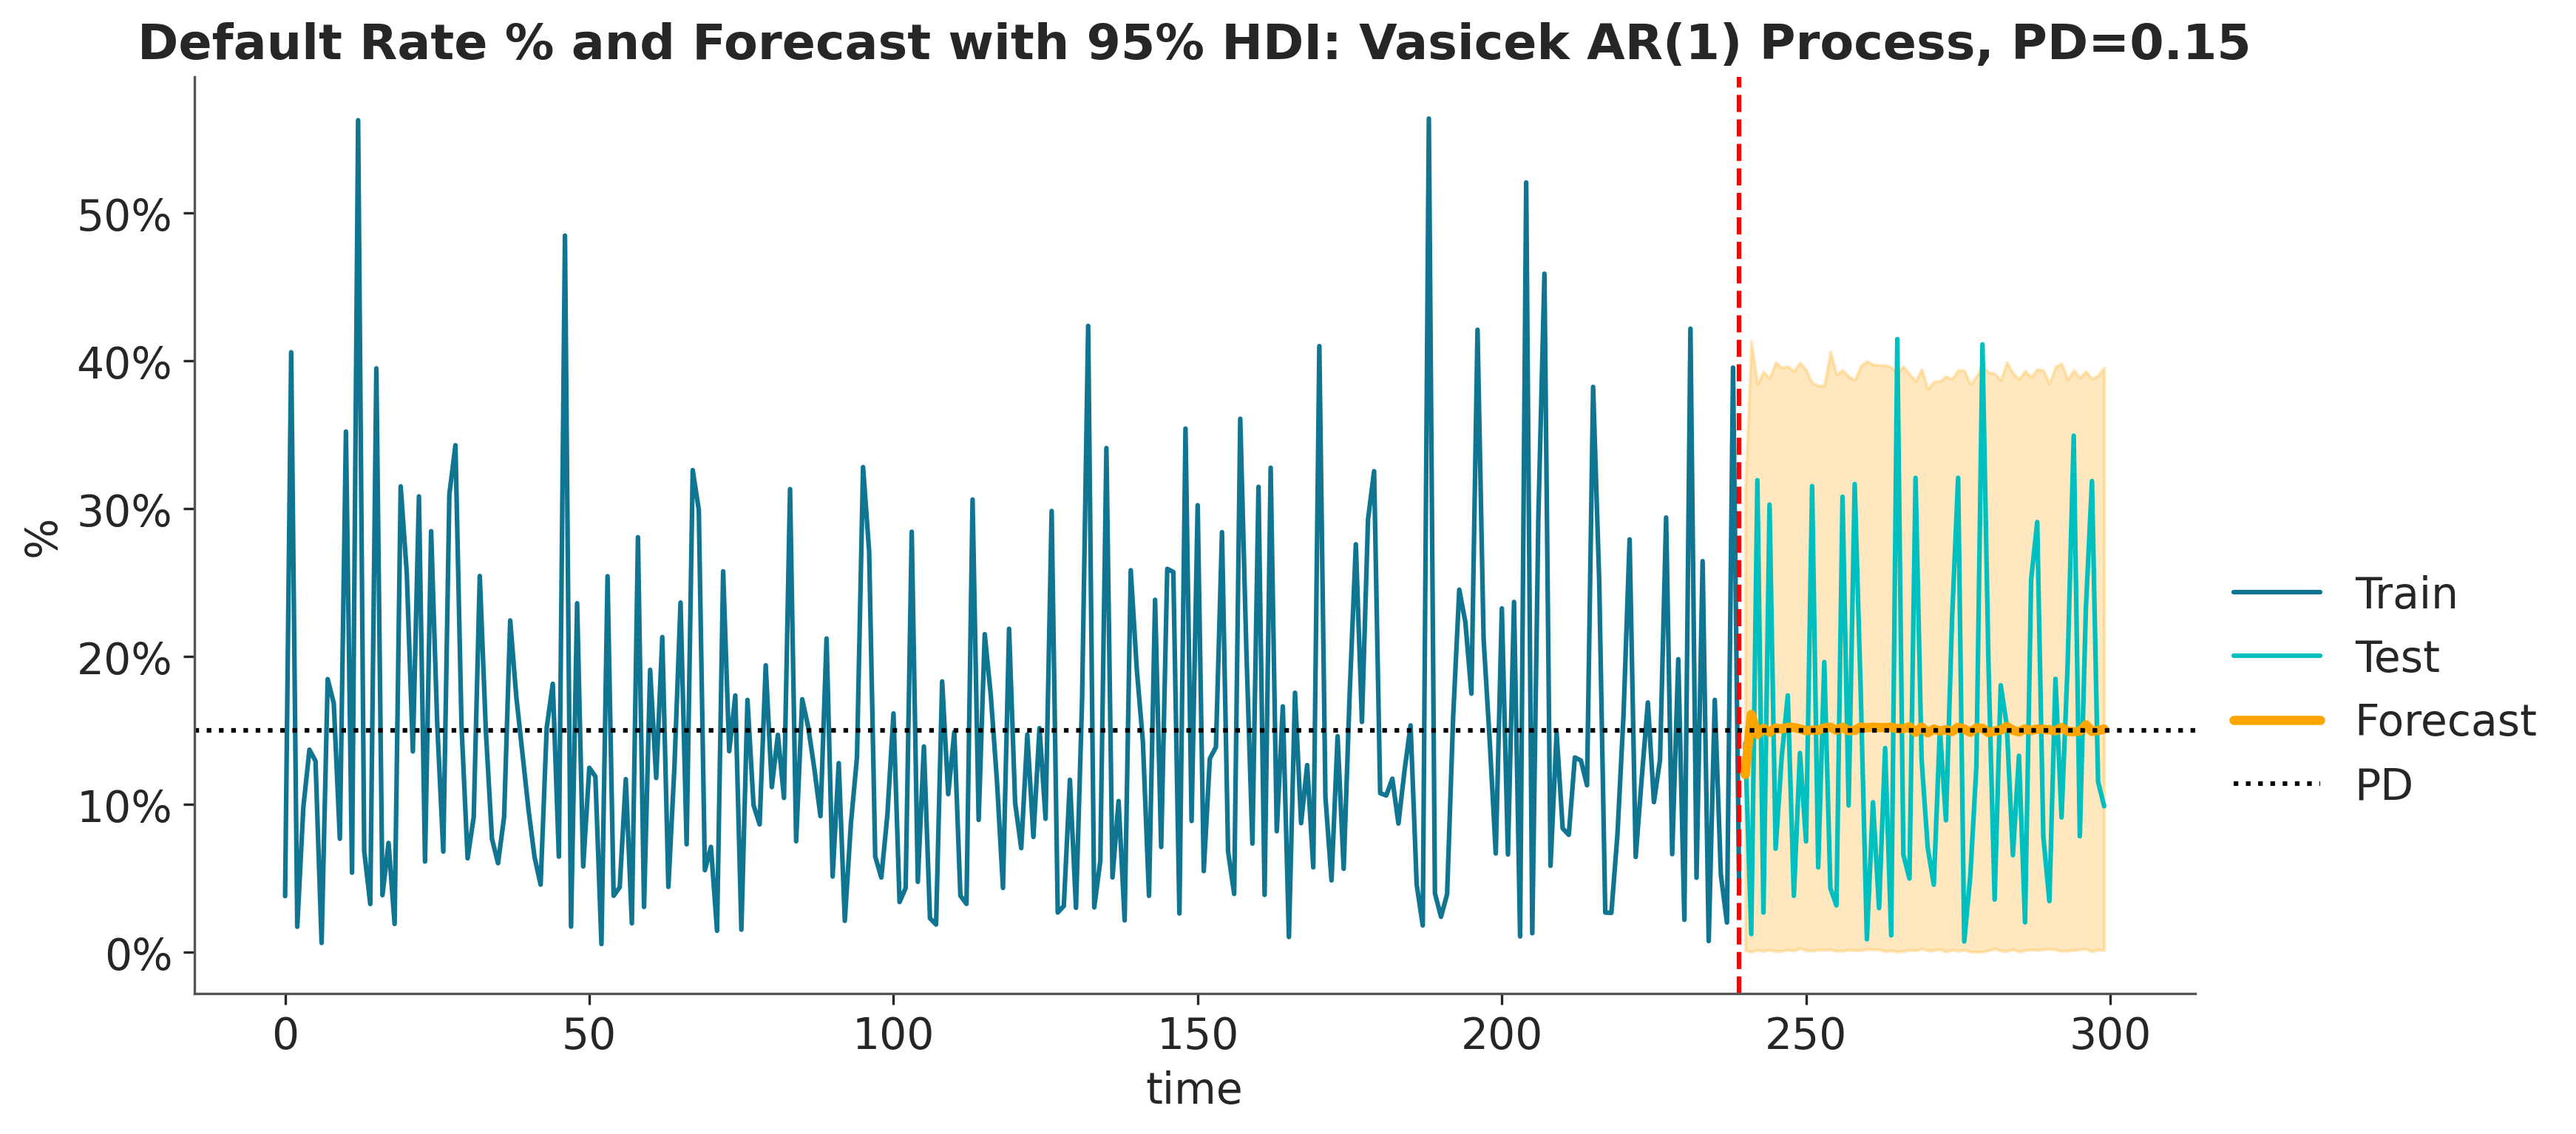

In [65]:
fig, ax = plt.subplots()

# Plotting Data
ax.plot(t_train, dr_train, color="C0", label="Train")
ax.plot(t_test, dr_test, color="C1", label="Test")
ax.axvline(t_train[-1], color="red", ls="--")

# Mean forecast
mean_forecast = idata_vasicek_forecast["posterior_predictive"]["forecast"].mean(dim=("chain", "draw")).values
# 95% HDI
hdi_95_int = az.hdi(idata_vasicek_forecast["posterior_predictive"]["forecast"], hdi_prob=0.95)["forecast"].to_numpy()
ax.plot(t_test, mean_forecast, color="orange", linewidth = 3, label="Forecast")
ax.fill_between(t_test, hdi_95_int[:, 0], hdi_95_int[:, 1], color="orange", alpha=0.25)

# Plot along with simulated PD
ax.axhline(PD_sim, color="k", ls=":", label="PD")

ax.set_xlabel("time")
ax.set_ylabel("%")
ax.set_title("Default Rate % and Forecast with 95% HDI: Vasicek AR(1) Process, PD={}".format(PD_sim))
ax.legend(bbox_to_anchor = (1, 0.5))
# Y-axis as percent
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()